# Aqua-Seq — 01. Data audit and EDA

**Aqua-Seq: Risk-Aware Water Safety Screening from Physicochemical Parameters**

This notebook answers one question before any modelling happens: *what is actually in
this dataset, and how much signal can we reasonably expect?*

It covers:

1. Shape, dtypes, duplicates, summary statistics and impossible values
2. Missing values — how much, where, and whether the missingness looks random
3. Target balance
4. Feature distributions overall and split by class
5. Outliers and correlations
6. Statistical tests of each feature against the target, with effect sizes
7. An honest read of what the plots show

> **Label convention.** The raw `Potability` column is `1` for potable (safe). Because a
> missed unsafe sample is the costly error, Aqua-Seq models **UNSAFE as the positive
> class**: `unsafe = 1 - Potability`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aqua_seq import config, data, evaluate, explain, features, models

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
evaluate.apply_style()

print("Aqua-Seq", __import__("aqua_seq").__version__)
print("Random seed:", config.RANDOM_SEED)

Aqua-Seq 1.0.0
Random seed: 42


## 1. Load the raw data and validate the schema

`data.load_raw()` raises a clear error if the CSV is missing or its columns do not match the expected Water Potability schema.

In [2]:
raw = data.load_raw()
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Shape: 3,276 rows x 10 columns


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
print("Dtypes:")
print(raw.dtypes.to_string())
print(f"\nDuplicate rows: {raw.duplicated().sum()}")
print(f"Fully-empty rows: {raw.isna().all(axis=1).sum()}")

Dtypes:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64

Duplicate rows: 0
Fully-empty rows: 0


### Summary statistics and a check for impossible values

pH is physically bounded to 0–14, and no physicochemical measurement here can be negative. Anything outside those bounds would be a data-quality red flag.

In [4]:
raw[config.FEATURES].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.081,1.594,0.000,6.093,7.037,8.062,14.000
Hardness,3276.0,196.369,32.880,47.432,176.851,196.968,216.667,323.124
Solids,3276.0,22014.093,8768.571,320.943,15666.690,20927.834,27332.762,61227.196
Chloramines,3276.0,7.122,1.583,0.352,6.127,7.130,8.115,13.127
Sulfate,2495.0,333.776,41.417,129.000,307.699,333.074,359.950,481.031
Conductivity,3276.0,426.205,80.824,181.484,365.734,421.885,481.792,753.343
Organic_carbon,3276.0,14.285,3.308,2.200,12.066,14.218,16.558,28.300
Trihalomethanes,3114.0,66.396,16.175,0.738,55.845,66.622,77.337,124.000
Turbidity,3276.0,3.967,0.780,1.450,3.440,3.955,4.500,6.739


In [5]:
impossible = {
    "ph below 0": int((raw["ph"] < 0).sum()),
    "ph above 14": int((raw["ph"] > 14).sum()),
    "any negative measurement": int((raw[config.FEATURES] < 0).sum().sum()),
    "ph exactly 0 (suspicious)": int((raw["ph"] == 0).sum()),
    "ph exactly 14 (suspicious)": int((raw["ph"] == 14).sum()),
}
for label, count in impossible.items():
    print(f"{label:30s} {count}")

ph below 0                     0
ph above 14                    0
any negative measurement       0
ph exactly 0 (suspicious)      1
ph exactly 14 (suspicious)     0


### A note on the `Solids` column

The Kaggle documentation labels `Solids` as total dissolved solids in **ppm**. Its median
is around 21,000 ppm — roughly **ten times** the BIS IS 10500:2012 *permissible* limit of
2,000 mg/L, for essentially every row. Either the units are not what the documentation
says, or these are not drinking-water samples. We report this rather than quietly
rescaling it, and it is the main reason the guideline rule baseline behaves the way it
does later on.

In [6]:
tds_limit = config.PARAMETER_LIMITS["Solids"].upper
share_above = (raw["Solids"] > tds_limit).mean()
print(f"BIS permissible TDS limit:       {tds_limit:,.0f} mg/L")
print(f"Median Solids in this dataset:   {raw['Solids'].median():,.0f}")
print(f"Share of rows above the limit:   {share_above:.1%}")

BIS permissible TDS limit:       2,000 mg/L
Median Solids in this dataset:   20,928
Share of rows above the limit:   99.8%


## 2. Missing values

Count and percent per column, then a check of whether missingness is related to the target.

In [7]:
missing = data.missingness_report(raw)
missing[missing["n_missing"] > 0]

,n_missing,pct_missing
Sulfate,781,23.84
ph,491,14.99
Trihalomethanes,162,4.95


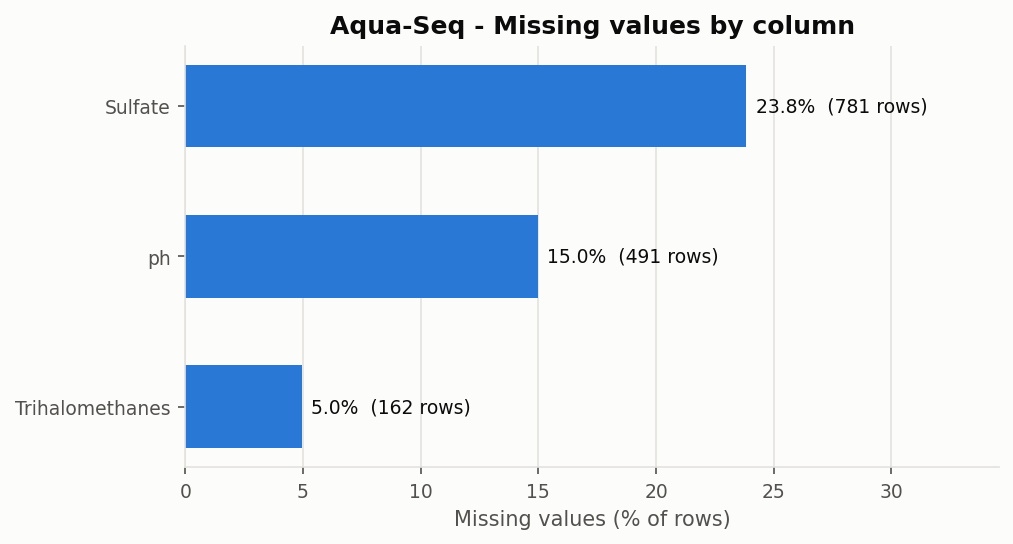

In [8]:
evaluate.plot_missingness(missing, "02_missingness")
from IPython.display import Image
Image(str(config.FIGURES_DIR / "02_missingness.png"))

### Is the missingness random?

If rows with a missing value were disproportionately unsafe, the *fact of being missing*
would itself be informative, and dropping or naively imputing those rows would bias the
model. We compare the unsafe rate among rows where a value is missing against rows where
it is present.

In [9]:
from scipy.stats import chi2_contingency

target = data.to_unsafe_label(raw)
rows = []
for column in missing[missing["n_missing"] > 0].index:
    flag = raw[column].isna()
    table = pd.crosstab(flag, target)
    chi2, p_value, _, _ = chi2_contingency(table)
    rows.append({
        "column": column,
        "n_missing": int(flag.sum()),
        "unsafe_rate_when_missing": target[flag].mean(),
        "unsafe_rate_when_present": target[~flag].mean(),
        "difference": target[flag].mean() - target[~flag].mean(),
        "chi2_p_value": p_value,
    })
pd.DataFrame(rows).round(4)

,column,n_missing,unsafe_rate_when_missing,unsafe_rate_when_present,difference,chi2_p_value
0,Sulfate,781,0.6248,0.6052,0.0196,0.3475
1,ph,491,0.6395,0.6047,0.0348,0.1588
2,Trihalomethanes,162,0.6605,0.6073,0.0532,0.2035


**Reading:** none of the three columns shows a large or clearly significant shift in the
unsafe rate between missing and present rows. The missingness is consistent with being
unrelated to the target (MCAR/MAR rather than informative). That justifies imputing
inside the pipeline rather than treating "missing" as a signal — though we still *test*
missing-indicator features under cross-validation in notebook 02 instead of assuming it.

## 3. Target balance

In [10]:
counts = target.value_counts().sort_index()
print(f"SAFE   (Potability=1): {counts[0]:,}  ({counts[0]/len(target):.1%})")
print(f"UNSAFE (Potability=0): {counts[1]:,}  ({counts[1]/len(target):.1%})")
print(f"\nUNSAFE is the MAJORITY class at {target.mean():.1%} prevalence.")

SAFE   (Potability=1): 1,278  (39.0%)
UNSAFE (Potability=0): 1,998  (61.0%)

UNSAFE is the MAJORITY class at 61.0% prevalence.


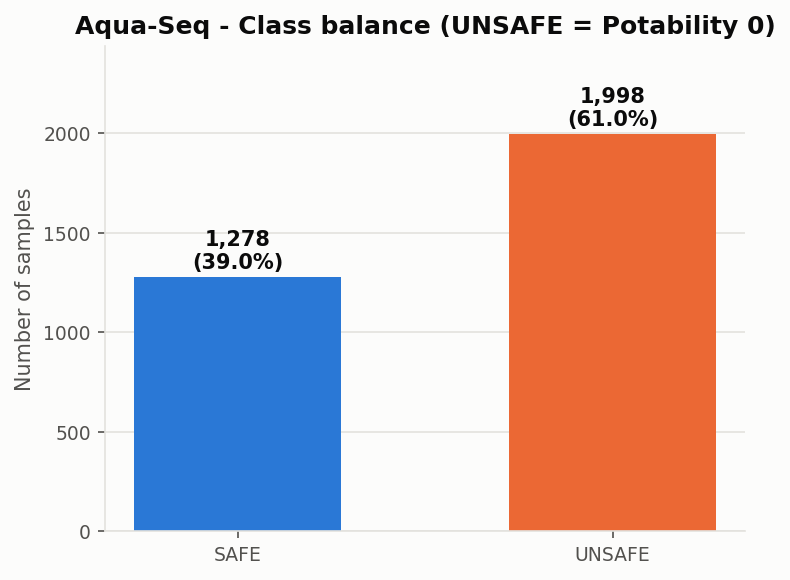

In [11]:
evaluate.plot_target_balance(target, "01_target_balance")
Image(str(config.FIGURES_DIR / "01_target_balance.png"))

**This matters more than it looks.** Because UNSAFE is the majority class, a trivial
"flag everything as unsafe" rule achieves **100% recall** on the class we care about, at
a precision equal to the base rate (~61%). Any useful model must beat that precision
*while* holding recall high — which is exactly what the threshold selection in notebook
03 is set up to do.

## 4. Feature distributions, overall and by class

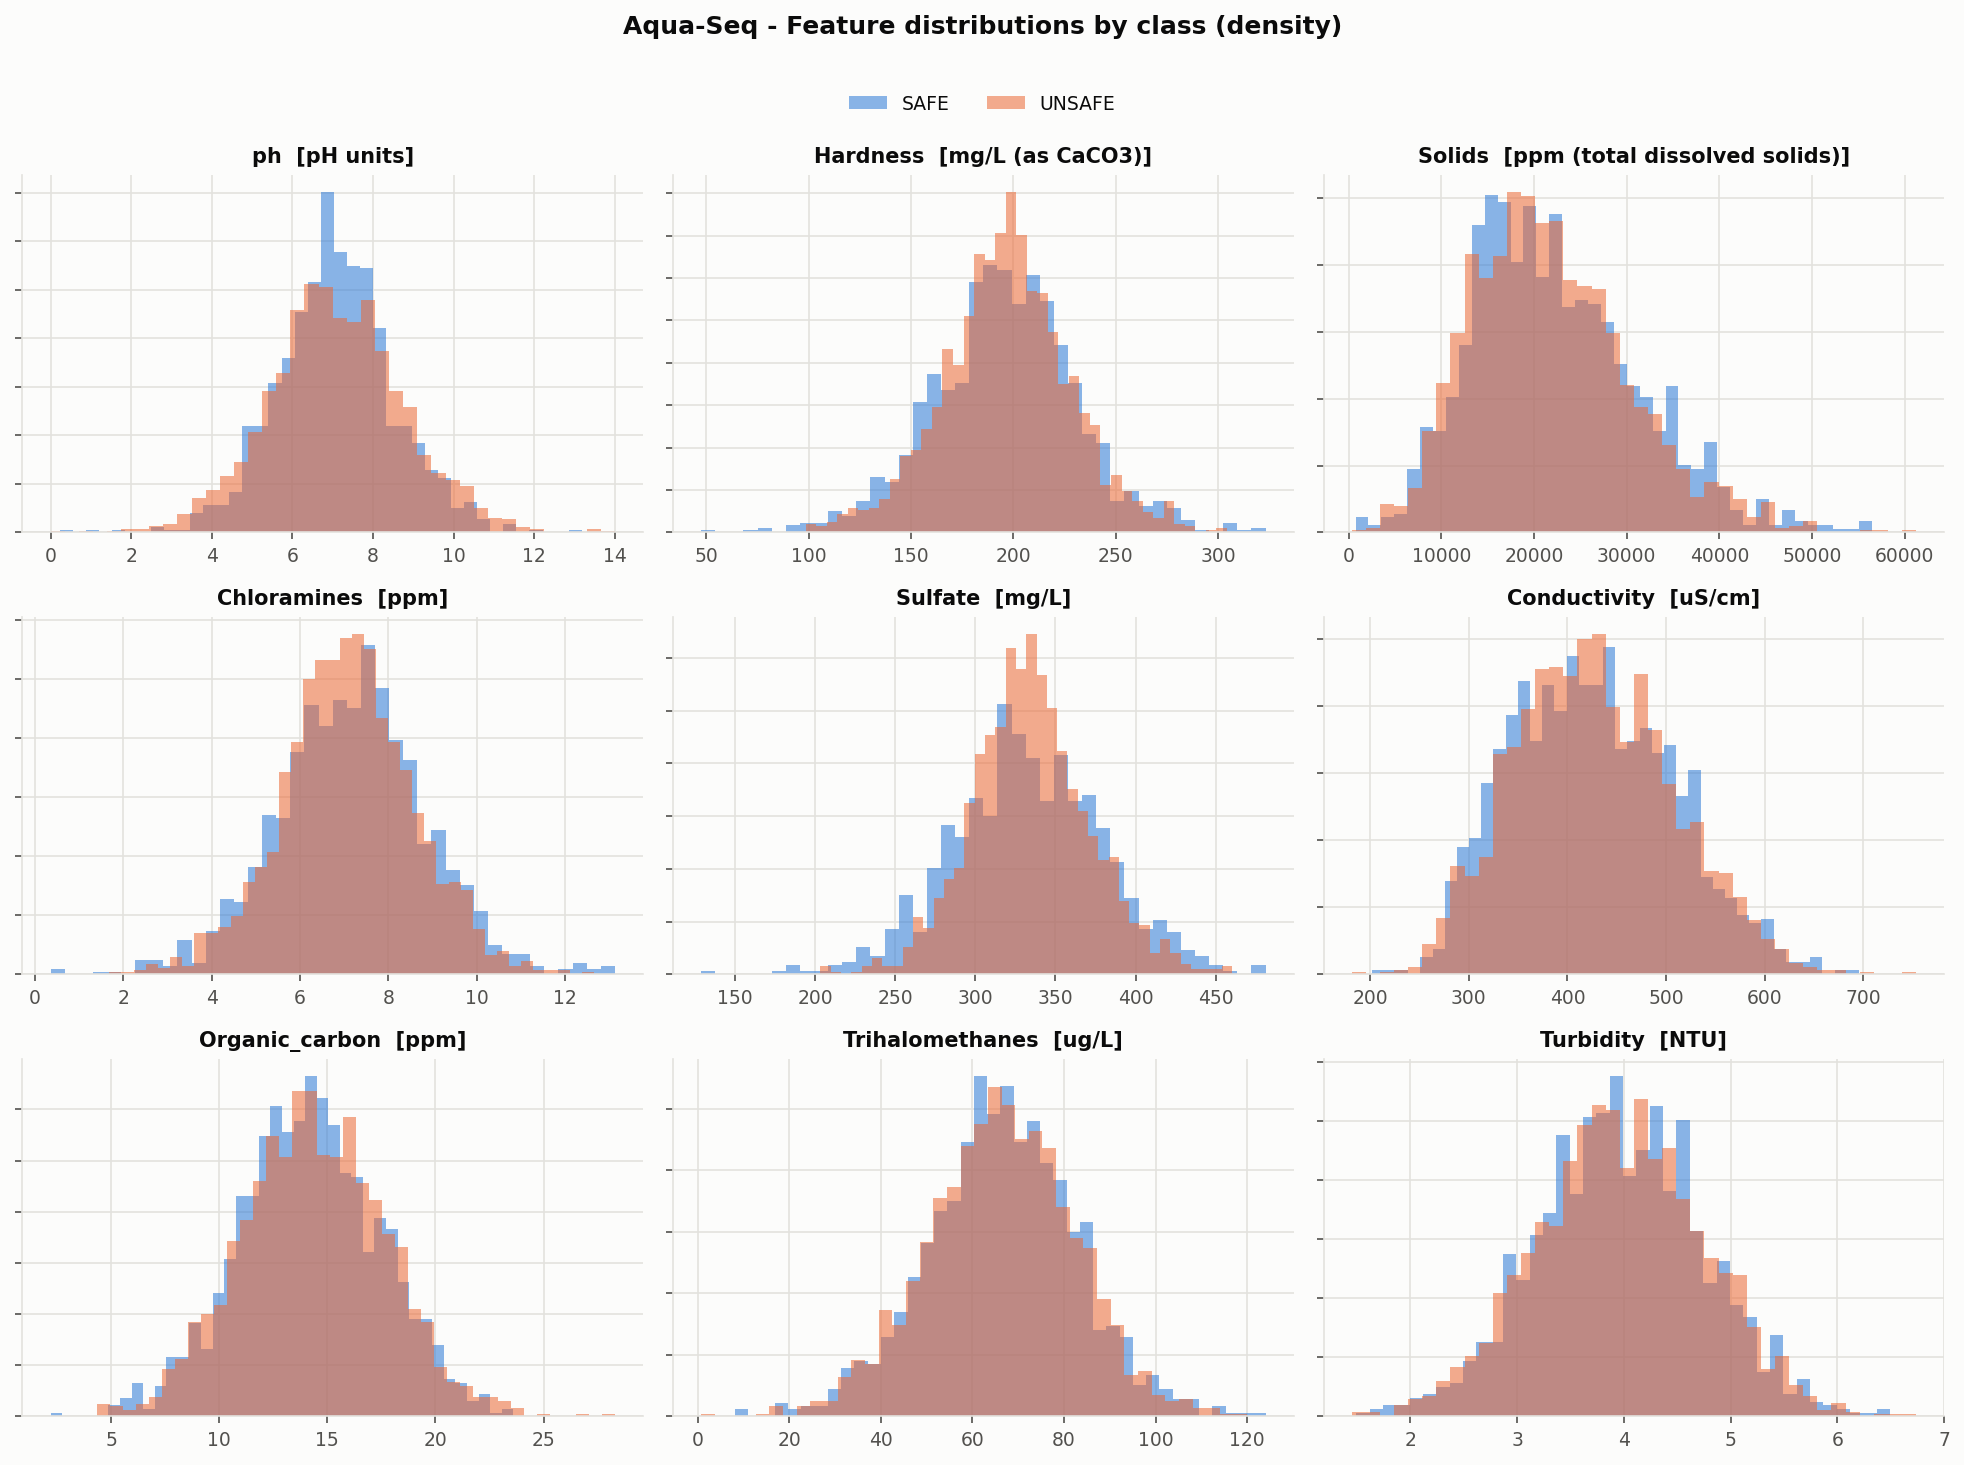

In [12]:
evaluate.plot_feature_distributions(raw[config.FEATURES], target, config.FEATURES, "03_feature_distributions")
Image(str(config.FIGURES_DIR / "03_feature_distributions.png"))

### Outliers

A boxplot per feature, standardised so all nine fit on one axis.

In [13]:
standardised = (raw[config.FEATURES] - raw[config.FEATURES].mean()) / raw[config.FEATURES].std()
fig, ax = plt.subplots(figsize=(11, 5))
box = ax.boxplot(
    [standardised[c].dropna() for c in config.FEATURES],
    tick_labels=config.FEATURES, patch_artist=True, widths=0.55,
)
for patch in box["boxes"]:
    patch.set_facecolor(evaluate.SERIES_COLORS[0])
    patch.set_alpha(0.55)
for element in ("medians", "whiskers", "caps"):
    for item in box[element]:
        item.set_color(evaluate.INK_SECONDARY)
for flier in box["fliers"]:
    flier.set(marker="o", markersize=3, markerfacecolor=evaluate.INK_MUTED,
              markeredgecolor="none", alpha=0.4)
ax.set_ylabel("Standardised value (z-score)")
ax.set_title("Aqua-Seq - Outlier check (all features standardised)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

iqr_outliers = {}
for column in config.FEATURES:
    series = raw[column].dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    iqr_outliers[column] = int(((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum())
pd.Series(iqr_outliers, name="n_outliers_1.5_IQR").sort_values(ascending=False).to_frame()

C:\Users\mohan\AppData\Local\Temp\ipykernel_13316\756705256.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,n_outliers_1.5_IQR
Hardness,83
Chloramines,61
Solids,47
ph,46
Sulfate,41
Trihalomethanes,33
Organic_carbon,25
Turbidity,19
Conductivity,11


## 5. Correlation

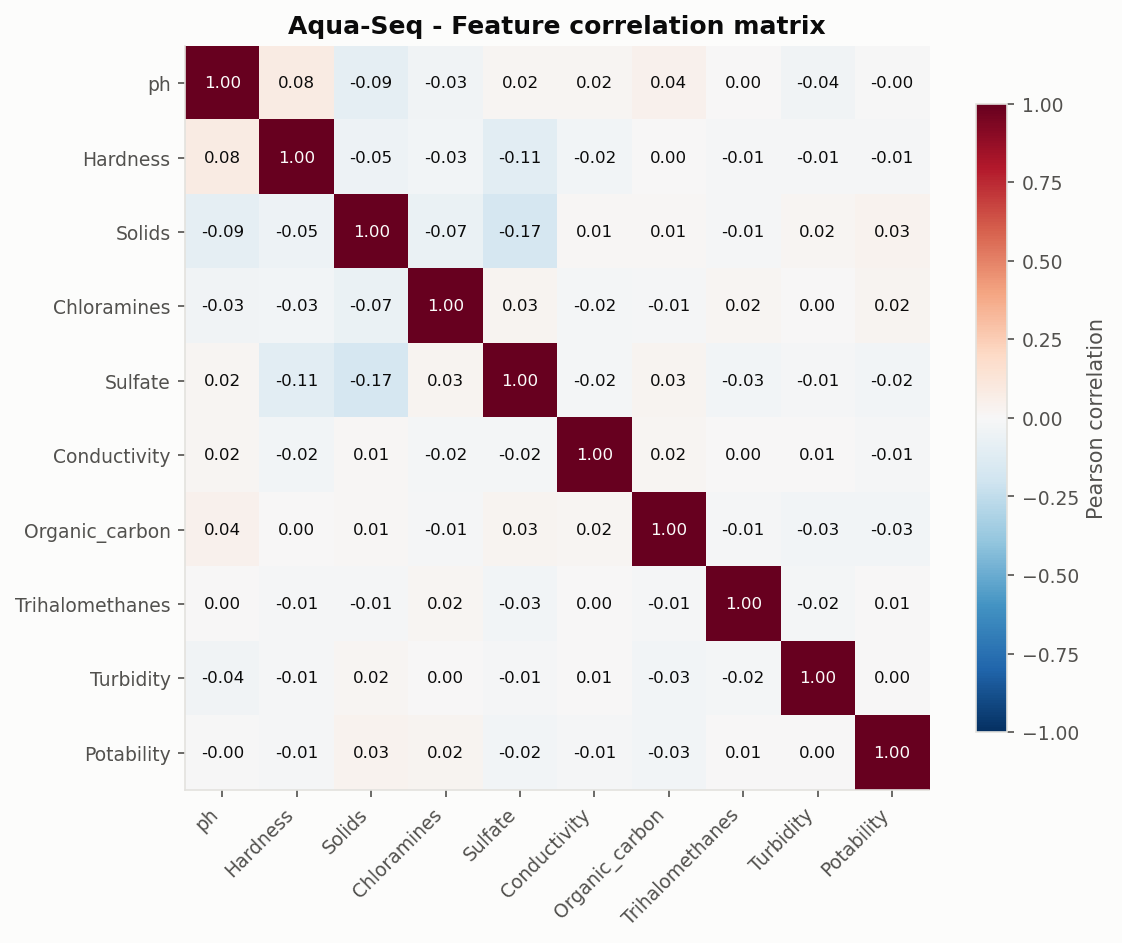

In [14]:
evaluate.plot_correlation_heatmap(raw[config.FEATURES + [config.RAW_TARGET]], "04_correlation_heatmap")
Image(str(config.FIGURES_DIR / "04_correlation_heatmap.png"))

In [15]:
correlation_with_target = (
    raw[config.FEATURES + [config.RAW_TARGET]].corr()[config.RAW_TARGET]
    .drop(config.RAW_TARGET).sort_values(key=abs, ascending=False)
)
print("Pearson correlation of each feature with Potability:")
print(correlation_with_target.round(4).to_string())
print(f"\nLargest absolute correlation: {correlation_with_target.abs().max():.4f}")

Pearson correlation of each feature with Potability:
Solids             0.0337
Organic_carbon    -0.0300
Chloramines        0.0238
Sulfate           -0.0236
Hardness          -0.0138
Conductivity      -0.0081
Trihalomethanes    0.0071
ph                -0.0036
Turbidity          0.0016

Largest absolute correlation: 0.0337


## 6. Statistical tests: each feature against the target

Mann-Whitney U (no normality assumption) with a rank-biserial correlation as the effect size. The effect size is bounded to [-1, 1]; 0 means the two class distributions are indistinguishable by rank.

In [16]:
from scipy.stats import mannwhitneyu

rows = []
for column in config.FEATURES:
    unsafe_values = raw.loc[target == 1, column].dropna()
    safe_values = raw.loc[target == 0, column].dropna()
    statistic, p_value = mannwhitneyu(unsafe_values, safe_values, alternative="two-sided")
    auc = statistic / (len(unsafe_values) * len(safe_values))
    rows.append({
        "feature": column,
        "median_unsafe": unsafe_values.median(),
        "median_safe": safe_values.median(),
        "p_value": p_value,
        "rank_biserial": 2 * auc - 1,
    })
tests = pd.DataFrame(rows).assign(abs_effect=lambda d: d["rank_biserial"].abs())
tests.sort_values("abs_effect", ascending=False).round(4).reset_index(drop=True)

,feature,median_unsafe,median_safe,p_value,rank_biserial,abs_effect
0,Organic_carbon,14.2935,14.1628,0.1255,0.0317,0.0317
1,Solids,20809.6183,21199.3866,0.1333,-0.0311,0.0311
2,Chloramines,7.0903,7.2152,0.1529,-0.0296,0.0296
3,Sulfate,333.3894,331.8382,0.4050,0.0197,0.0197
4,Hardness,197.1234,196.6329,0.5439,0.0126,0.0126
5,Conductivity,422.2293,420.7127,0.5523,0.0123,0.0123
6,Trihalomethanes,66.5422,66.6782,0.7672,-0.0063,0.0063
7,ph,7.0355,7.0368,0.9084,0.0026,0.0026
8,Turbidity,3.9481,3.9586,0.9504,-0.0013,0.0013


In [17]:
significant = tests[tests["p_value"] < 0.05]
print(f"Features significant at p < 0.05: {len(significant)} of {len(tests)}")
if len(significant):
    print(significant[["feature", "p_value", "rank_biserial"]].round(4).to_string(index=False))
print(f"\nLargest absolute effect size across all features: {tests['abs_effect'].max():.4f}")
print("For reference, |rank-biserial| of 0.1 is conventionally a 'small' effect.")

Features significant at p < 0.05: 0 of 9

Largest absolute effect size across all features: 0.0317
For reference, |rank-biserial| of 0.1 is conventionally a 'small' effect.


## 7. Key observations

Only what the plots and tests above actually show:

1. **The dataset is 3,276 rows with no duplicates and no impossible values.** pH stays
   within 0–14 and nothing is negative. There are IQR outliers in every feature, but they
   are consistent with heavy-tailed measurement distributions rather than data corruption.

2. **UNSAFE is the majority class (~61%).** This inverts the usual imbalance framing: the
   costly class is the common one, so "flag everything" already achieves perfect recall.
   Precision is the scarce quantity.

3. **Missing values are substantial but appear unrelated to the target.** `Sulfate` (23.8%),
   `ph` (15.0%) and `Trihalomethanes` (4.9%) have gaps, yet the unsafe rate barely moves
   between missing and present rows. Imputation inside the pipeline is the right call.

4. **The class-conditional distributions overlap almost completely.** In the per-feature
   density panels, the SAFE and UNSAFE curves sit on top of each other for all nine
   parameters. No feature visually separates the classes.

5. **The statistical tests agree with the plots: the univariate signal is very weak.**
   Every absolute rank-biserial effect size is far below the 0.1 "small effect" convention,
   and feature–target correlations are near zero. Features are also nearly uncorrelated
   with each other, so there is no obvious multicollinearity to exploit or remove.

6. **The `Solids` column is inconsistent with its documented units** — a median around
   21,000 ppm against a 2,000 mg/L permissible limit. We report this rather than silently
   rescaling.

**What this implies for modelling.** We should expect modest performance and should be
suspicious of any result that looks strong. The honest goal is not a high accuracy number;
it is to find out whether a model can hold high recall on unsafe samples at a *better
precision than simply flagging everything*, and to say clearly if it cannot.

Next: **02_baselines_and_modeling.ipynb**.